# Sports Image Classification

This notebook presents the results of a sports image classification project based on **already completed training runs**.

The notebook is used for:
- loading saved experiment outputs,
- comparing multiple experiments,
- visualizing training and evaluation results,
- reusing the saved best model checkpoints for example predictions.

The training itself is handled by the project scripts outside this notebook.  
This notebook only reads saved artifacts from the project folders and does not modify the training pipeline.


## 1. Environment setup

The notebook assumes it is opened from the **project root directory**.  
All paths are therefore handled **relatively**, mainly through the `outputs/` folder created by the training runs.


In [12]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Outputs root:", OUTPUT_ROOT)

try:
    from config import list_experiments
    from src.utils import load_json, load_class_mapping, get_device, set_seed
    from src.transforms import build_transforms
    from src.model import create_model
    PROJECT_IMPORTS_OK = True
    set_seed(42)
    print("Device:", get_device())
except Exception as e:
    PROJECT_IMPORTS_OK = False
    print("Project imports are not available:", e)


Project root: c:\Users\valiceks\school\NSIETE-Projekt\sports_project
Outputs root: c:\Users\valiceks\school\NSIETE-Projekt\sports_project\outputs
Device: cpu


## 2. Available experiment runs

The following cell searches the `outputs/` directory and selects the latest saved run for each experiment.


In [13]:
def safe_load_json(path: Path):
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return None

def find_run_dirs(output_root: Path):
    if not output_root.exists():
        return []
    return [p for p in output_root.iterdir() if p.is_dir()]

def latest_runs_by_experiment(output_root: Path):
    runs = find_run_dirs(output_root)
    grouped = {}
    for run in runs:
        name = run.name
        parts = name.rsplit("_", 2)
        experiment = parts[0] if len(parts) >= 3 else name
        grouped.setdefault(experiment, []).append(run)
    latest = {}
    for exp, exp_runs in grouped.items():
        latest[exp] = sorted(exp_runs)[-1]
    return latest

latest_runs = latest_runs_by_experiment(OUTPUT_ROOT)

if not latest_runs:
    print("No completed runs were found in outputs/.")
else:
    for exp, path in sorted(latest_runs.items()):
        print(f"{exp}: {path.relative_to(PROJECT_ROOT)}")


baseline_no_aug: outputs\baseline_no_aug_20260413_222210
brightness_aug: outputs\brightness_aug_20260413_212959
moderate_aug: outputs\moderate_aug_20260413_203330


## 3. Summary table of experiments

This section loads the main saved metrics for all available runs and builds one comparison table.


In [14]:
rows = []

for exp, run_dir in sorted(latest_runs.items()):
    summary_path = run_dir / "metrics" / "summary_metrics.json"
    config_path = run_dir / "config_used.json"

    summary = safe_load_json(summary_path)
    config = safe_load_json(config_path)

    if summary is None:
        continue

    val_metrics = summary.get("val_metrics", {})
    test_metrics = summary.get("test_metrics", {})
    dataset_sizes = summary.get("dataset_sizes", {})

    rows.append({
        "experiment": summary.get("experiment", exp),
        "model_name": summary.get("model_name", config.get("model_name") if config else None),
        "augmentation_mode": config.get("augmentation_mode") if config else None,
        "best_epoch": summary.get("best_epoch"),
        "val_accuracy": val_metrics.get("accuracy"),
        "val_macro_f1": val_metrics.get("macro_f1"),
        "test_accuracy": test_metrics.get("accuracy"),
        "test_macro_f1": test_metrics.get("macro_f1"),
        "top_3_accuracy": test_metrics.get("top_3_accuracy"),
        "top_5_accuracy": test_metrics.get("top_5_accuracy"),
        "train_size": dataset_sizes.get("train"),
        "val_size": dataset_sizes.get("val"),
        "test_size": dataset_sizes.get("test"),
        "run_dir": str(run_dir.relative_to(PROJECT_ROOT)),
    })

results_df = pd.DataFrame(rows)

if results_df.empty:
    print("No experiment summaries could be loaded.")
else:
    results_df = results_df.sort_values(["test_macro_f1", "test_accuracy"], ascending=False).reset_index(drop=True)
    display(results_df)


,experiment,model_name,augmentation_mode,best_epoch,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,top_3_accuracy,top_5_accuracy,train_size,val_size,test_size,run_dir
0,brightness_aug,resnet18,brightness_aug,4,0.888,0.888513,0.916,0.915794,0.982,0.992,13492,500,500,outputs\brightness_aug_20260413_212959
1,baseline_no_aug,resnet18,none,4,0.874,0.875856,0.912,0.911231,0.980,0.990,13492,500,500,outputs\baseline_no_aug_20260413_222210
2,moderate_aug,resnet18,moderate_aug,4,0.842,0.841883,0.844,0.841502,0.964,0.976,13492,500,500,outputs\moderate_aug_20260413_203330


## 4. Comparison of final metrics

The next charts compare the final performance of all available experiments.


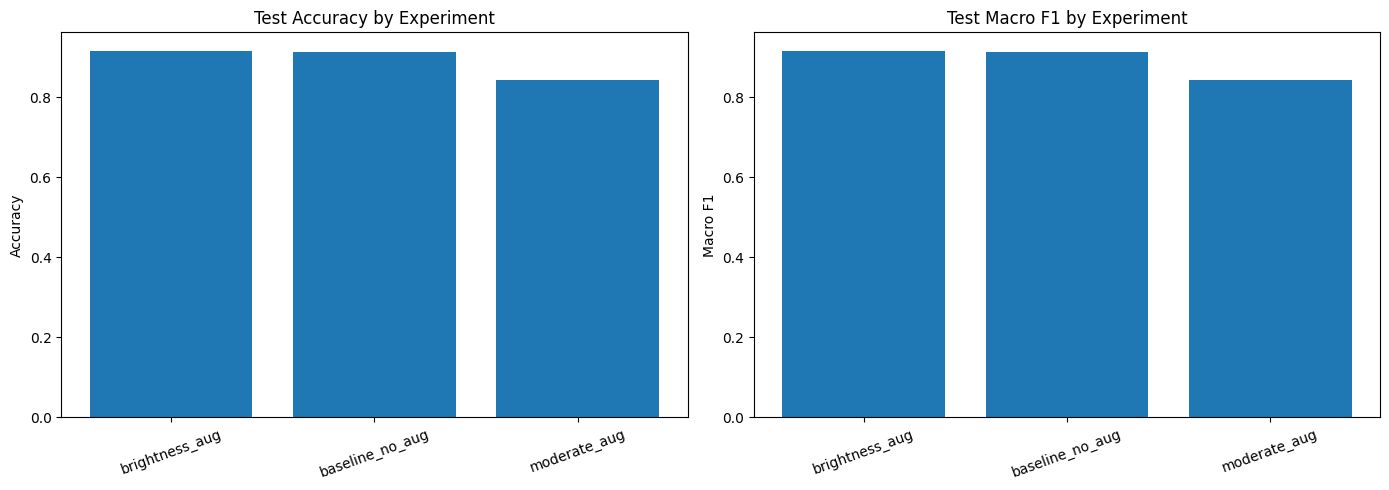

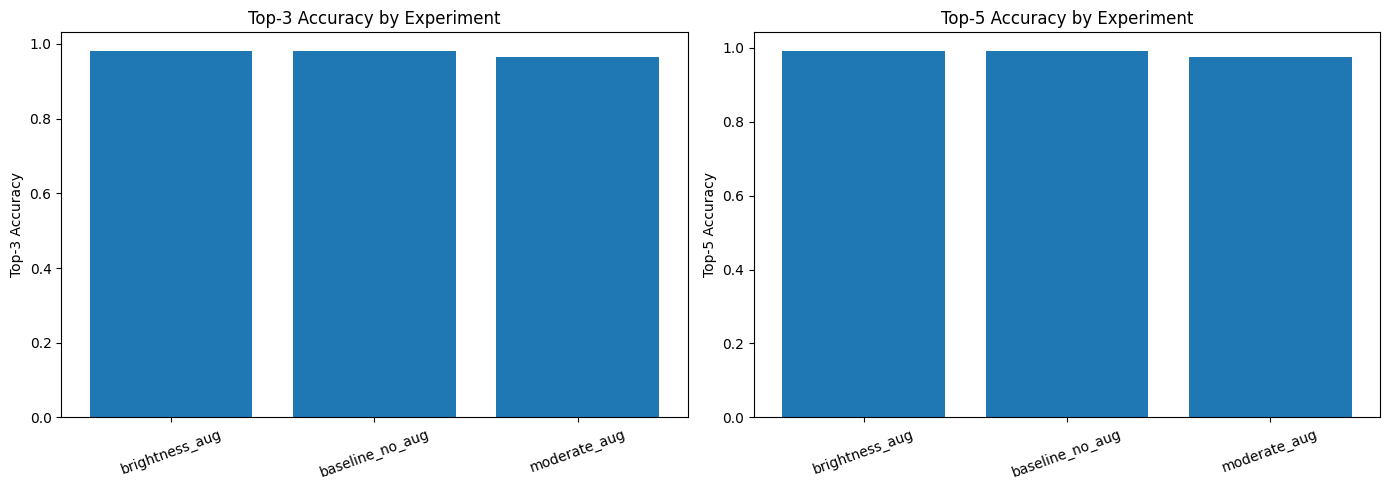

In [15]:
if results_df.empty:
    print("No results available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(results_df["experiment"], results_df["test_accuracy"])
    axes[0].set_title("Test Accuracy by Experiment")
    axes[0].set_ylabel("Accuracy")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(results_df["experiment"], results_df["test_macro_f1"])
    axes[1].set_title("Test Macro F1 by Experiment")
    axes[1].set_ylabel("Macro F1")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

    if "top_3_accuracy" in results_df.columns and "top_5_accuracy" in results_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].bar(results_df["experiment"], results_df["top_3_accuracy"])
        axes[0].set_title("Top-3 Accuracy by Experiment")
        axes[0].set_ylabel("Top-3 Accuracy")
        axes[0].tick_params(axis="x", rotation=20)

        axes[1].bar(results_df["experiment"], results_df["top_5_accuracy"])
        axes[1].set_title("Top-5 Accuracy by Experiment")
        axes[1].set_ylabel("Top-5 Accuracy")
        axes[1].tick_params(axis="x", rotation=20)

        plt.tight_layout()
        plt.show()


## 5. Best experiment

The best experiment is selected according to **test macro F1**, with **test accuracy** used as a secondary criterion.


In [16]:
if results_df.empty:
    best_row = None
    print("No experiment results available.")
else:
    best_row = results_df.iloc[0]
    display(best_row.to_frame("value"))


,value
experiment,brightness_aug
model_name,resnet18
augmentation_mode,brightness_aug
best_epoch,4
val_accuracy,0.888
val_macro_f1,0.888513
test_accuracy,0.916
test_macro_f1,0.915794
top_3_accuracy,0.982
top_5_accuracy,0.992


## 6. Training dynamics

The following plots show how loss and accuracy developed during training for each available run.


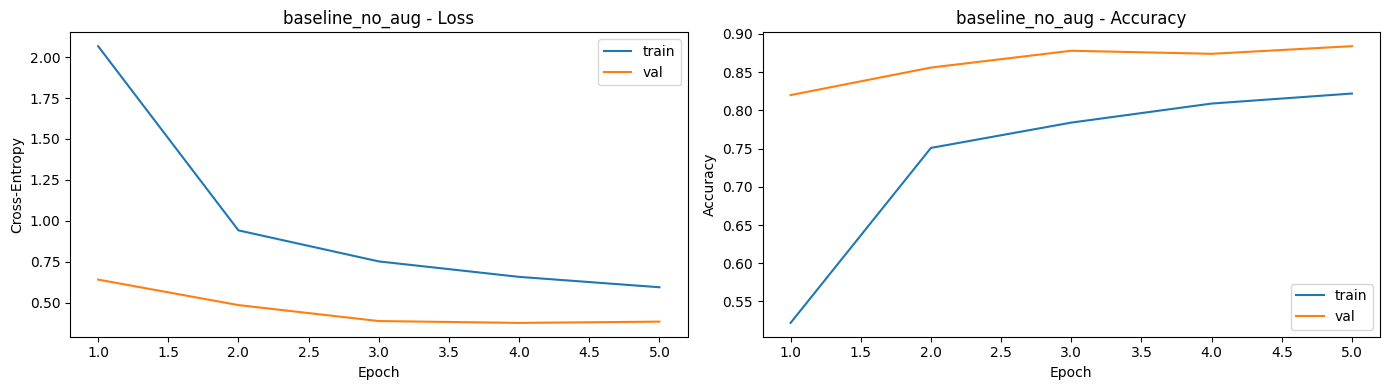

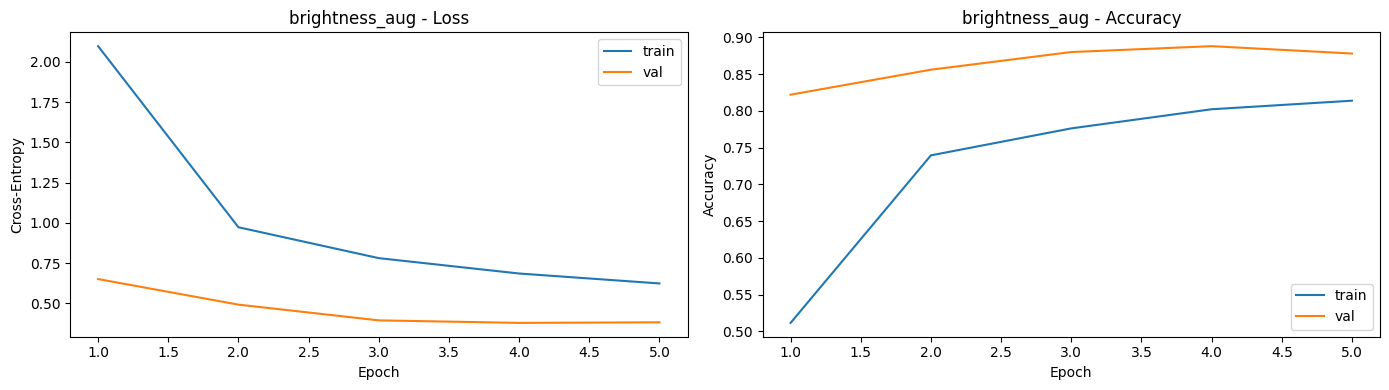

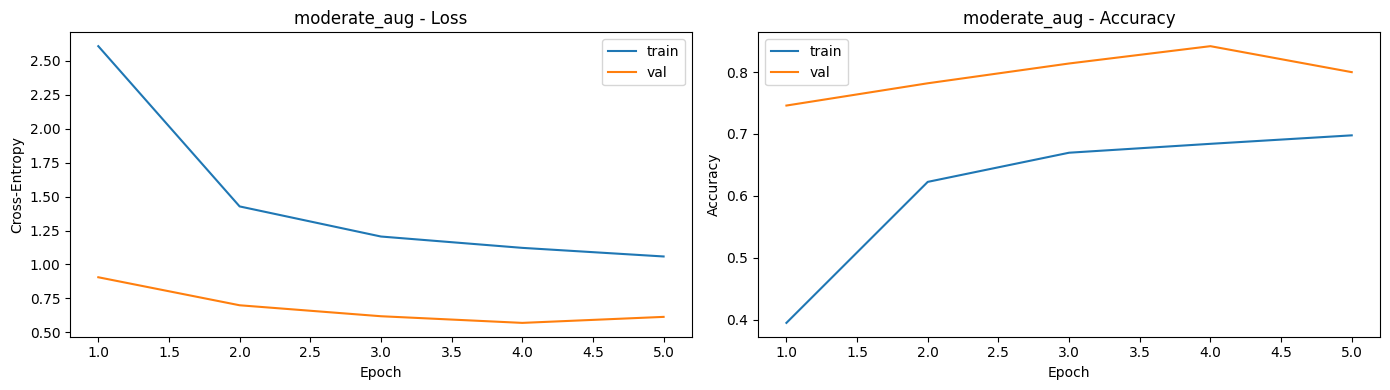

In [17]:
def show_history(run_dir: Path, title: str):
    history_path = run_dir / "metrics" / "epoch_history.csv"
    if not history_path.exists():
        print(f"No history found for {title}")
        return

    hist = pd.read_csv(history_path)
    if hist.empty:
        print(f"Empty history for {title}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
    axes[0].plot(hist["epoch"], hist["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy")
    axes[0].legend()

    axes[1].plot(hist["epoch"], hist["train_acc"], label="train")
    axes[1].plot(hist["epoch"], hist["val_acc"], label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

for exp, run_dir in sorted(latest_runs.items()):
    show_history(run_dir, exp)


## 7. Class distribution in the training split

This part uses the saved split files of the best experiment to visualize the class distribution.


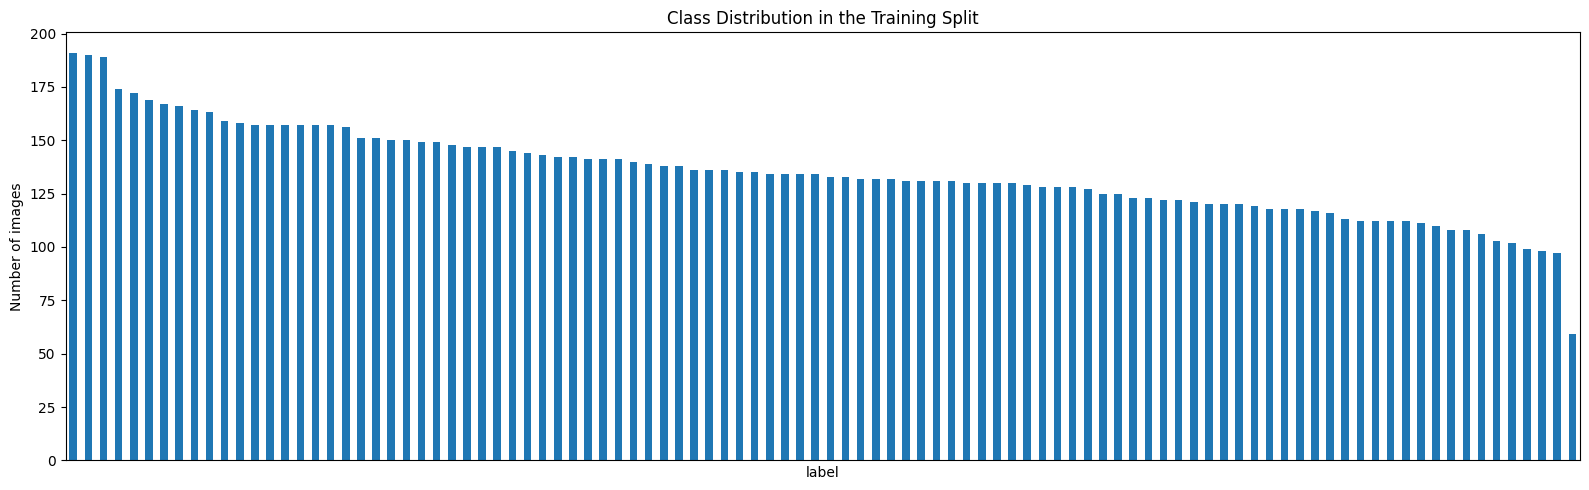

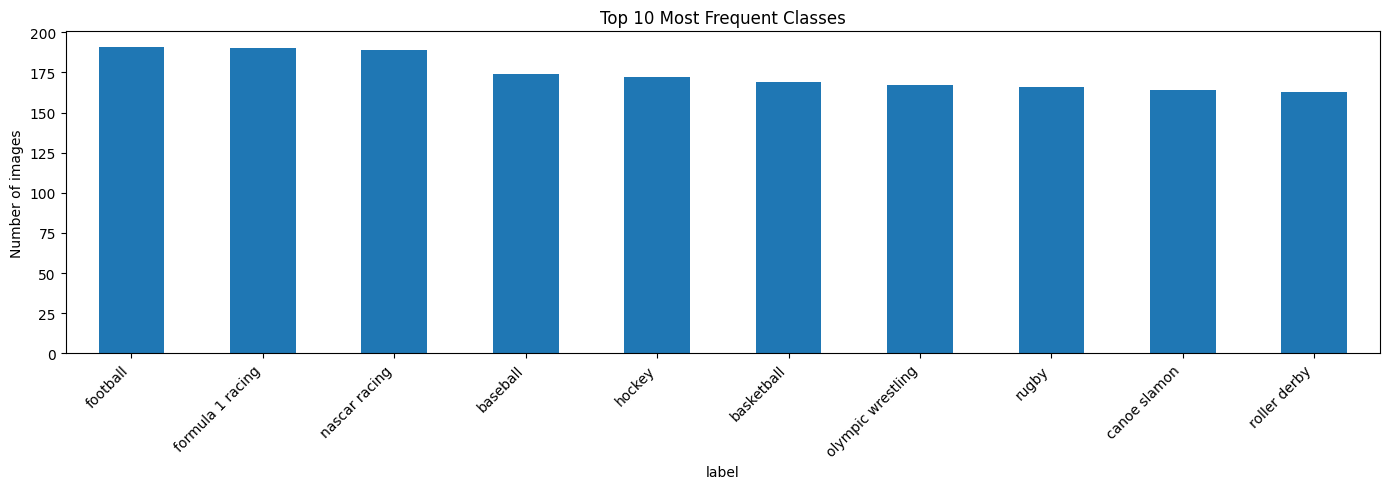

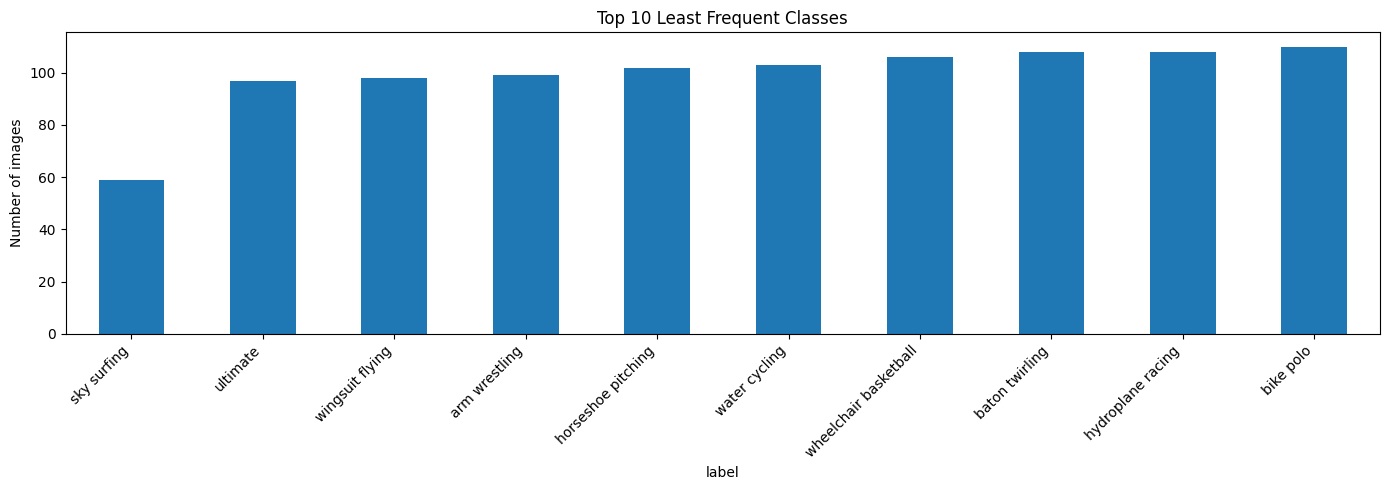

In [18]:
def count_classes_from_csv(csv_path: Path):
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if "label" not in df.columns:
        return None
    return df["label"].value_counts()

if best_row is None:
    print("Best run is not available.")
else:
    best_run_dir = PROJECT_ROOT / best_row["run_dir"]
    train_csv = best_run_dir / "splits" / "train.csv"
    train_counts = count_classes_from_csv(train_csv)

    if train_counts is None:
        print("Training split CSV is not available.")
    else:
        plt.figure(figsize=(16, 5))
        train_counts.sort_values(ascending=False).plot(kind="bar")
        plt.title("Class Distribution in the Training Split")
        plt.ylabel("Number of images")
        plt.xticks([], [])
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(14, 5))
        train_counts.sort_values(ascending=False).head(10).plot(kind="bar")
        plt.title("Top 10 Most Frequent Classes")
        plt.ylabel("Number of images")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(14, 5))
        train_counts.sort_values(ascending=True).head(10).plot(kind="bar")
        plt.title("Top 10 Least Frequent Classes")
        plt.ylabel("Number of images")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


## 8. Saved confusion matrix of the best run

The saved confusion matrix is displayed below for the best experiment.


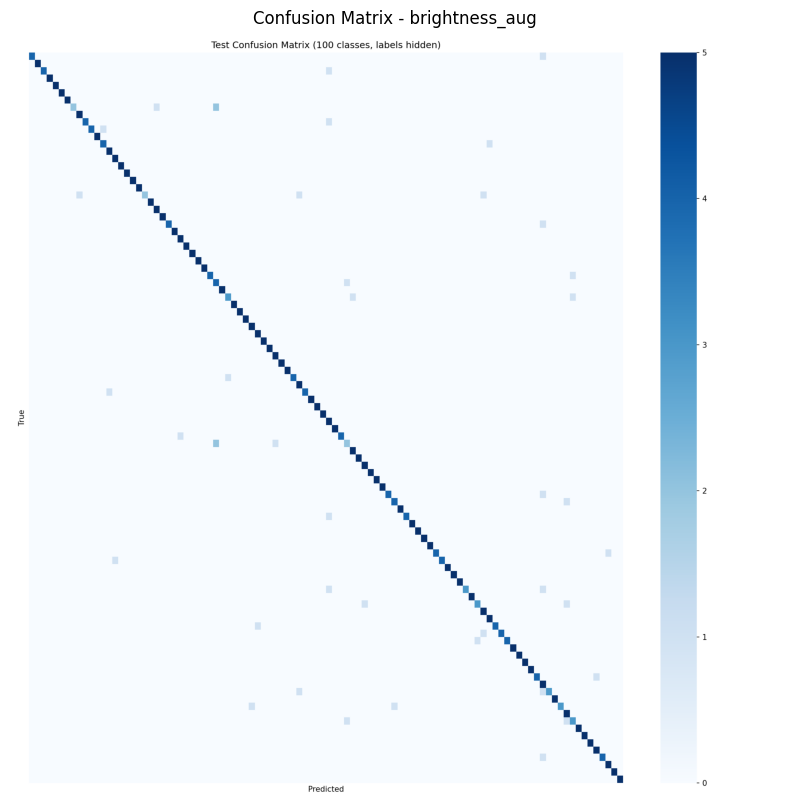

In [19]:
if best_row is None:
    print("Best run is not available.")
else:
    best_run_dir = PROJECT_ROOT / best_row["run_dir"]
    cm_plot = best_run_dir / "plots" / "test_confusion_matrix.png"

    if cm_plot.exists():
        img = Image.open(cm_plot)
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Confusion Matrix - {best_row['experiment']}")
        plt.show()
    else:
        print("No saved confusion matrix plot found.")


## 9. Detailed evaluation of the best run

This section loads the saved summary and classification report of the best-performing experiment.


In [20]:
if best_row is None:
    print("Best run is not available.")
else:
    best_run_dir = PROJECT_ROOT / best_row["run_dir"]
    summary = safe_load_json(best_run_dir / "metrics" / "summary_metrics.json")
    report_json = safe_load_json(best_run_dir / "metrics" / "test_classification_report.json")
    report_txt_path = best_run_dir / "metrics" / "test_classification_report.txt"

    if summary is not None:
        display(pd.json_normalize(summary, sep="."))

    if report_json is not None:
        report_df = pd.DataFrame(report_json).T
        display(report_df.head(20))
    elif report_txt_path.exists():
        print(report_txt_path.read_text(encoding="utf-8"))
    else:
        print("No classification report found.")


,experiment,model_name,best_epoch,num_classes,class_merge_enabled,dataset_sizes.train,dataset_sizes.val,dataset_sizes.test,split_layout.has_split_layout,split_layout.train,...,val_metrics.top_5_accuracy,val_metrics.loss,test_metrics.accuracy,test_metrics.macro_precision,test_metrics.macro_recall,test_metrics.macro_f1,test_metrics.top_1_accuracy,test_metrics.top_3_accuracy,test_metrics.top_5_accuracy,test_metrics.loss
0,brightness_aug,resnet18,4,100,False,13492,500,500,True,C:\Users\valiceks\.cache\kagglehub\datasets\gp...,...,0.99,0.379382,0.916,0.93597,0.916,0.915794,0.916,0.982,0.992,0.297561


,precision,recall,f1-score,support
air hockey,1.000000,0.8,0.888889,5.0
ampute football,1.000000,1.0,1.000000,5.0
archery,1.000000,0.8,0.888889,5.0
arm wrestling,1.000000,1.0,1.000000,5.0
axe throwing,1.000000,1.0,1.000000,5.0
balance beam,1.000000,1.0,1.000000,5.0
barell racing,1.000000,1.0,1.000000,5.0
baseball,1.000000,0.4,0.571429,5.0
basketball,0.833333,1.0,0.909091,5.0
baton twirling,1.000000,0.8,0.888889,5.0


## 10. Example images from the test split

A small sample of images from the test split is shown below to illustrate the dataset used for evaluation.


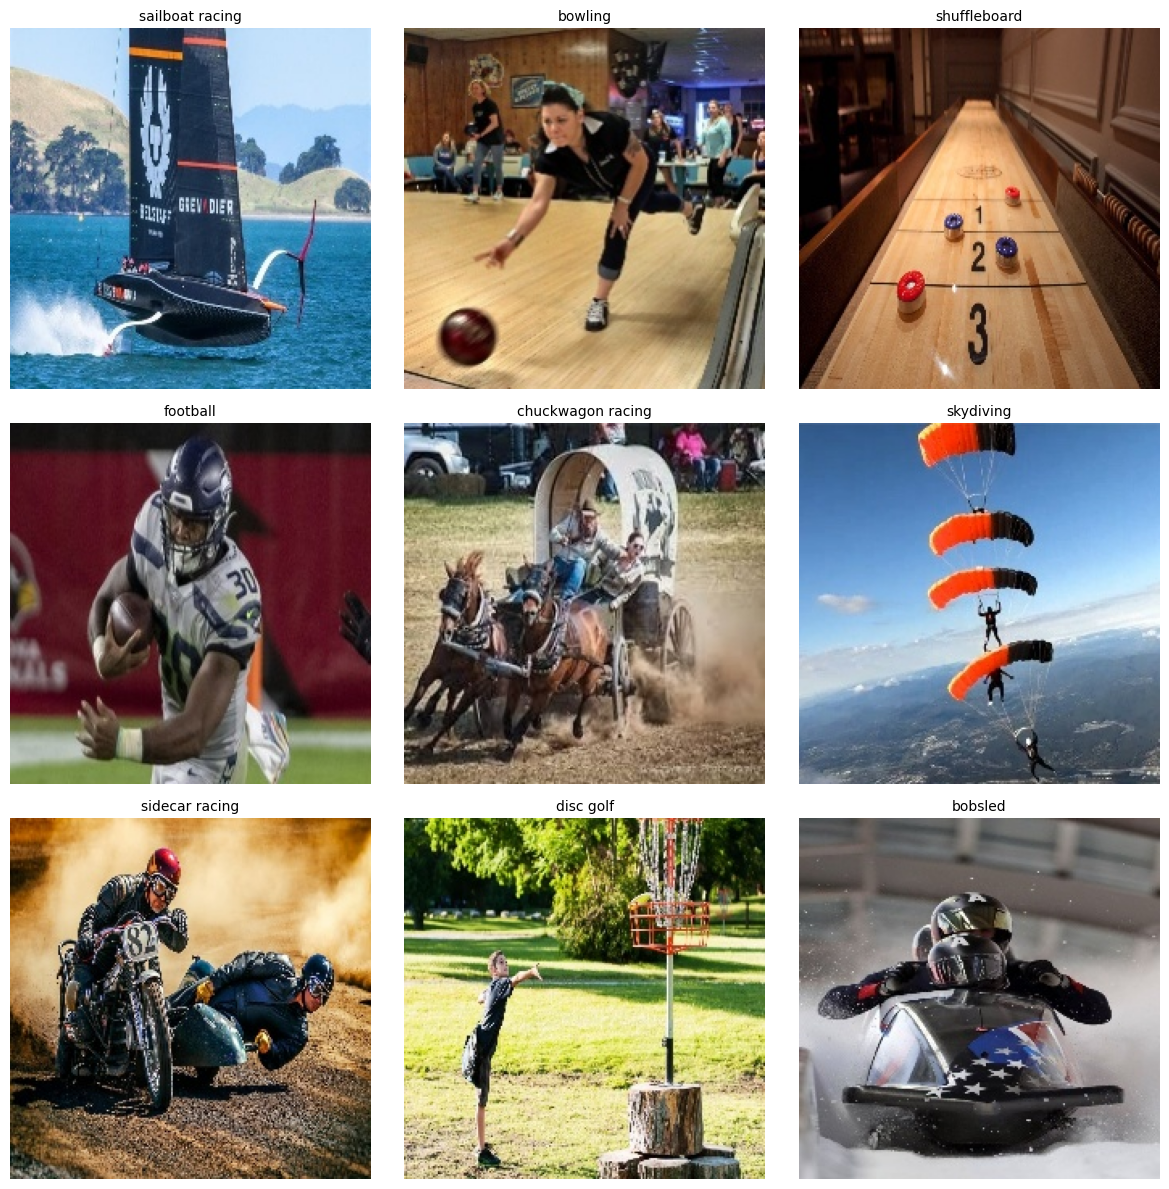

In [21]:
if best_row is None:
    print("Best run is not available.")
else:
    best_run_dir = PROJECT_ROOT / best_row["run_dir"]
    test_csv = best_run_dir / "splits" / "test.csv"

    if not test_csv.exists():
        print("Saved test split CSV not found.")
    else:
        test_df = pd.read_csv(test_csv)
        if test_df.empty:
            print("Test split is empty.")
        else:
            sample_df = test_df.sample(min(9, len(test_df)), random_state=42).reset_index(drop=True)

            fig, axes = plt.subplots(3, 3, figsize=(12, 12))
            axes = axes.flatten()

            for ax, row in zip(axes, sample_df.to_dict(orient="records")):
                image_path = Path(row["path"])
                label = row["label"]
                try:
                    with Image.open(image_path) as img:
                        ax.imshow(img.convert("RGB"))
                    ax.set_title(label, fontsize=10)
                    ax.axis("off")
                except Exception:
                    ax.set_title(f"Missing image\n{label}", fontsize=10)
                    ax.axis("off")

            for ax in axes[len(sample_df):]:
                ax.axis("off")

            plt.tight_layout()
            plt.show()


## 11. Example predictions from the best saved model

The following section reloads the saved checkpoint of the best experiment and applies it to a small sample of test images.


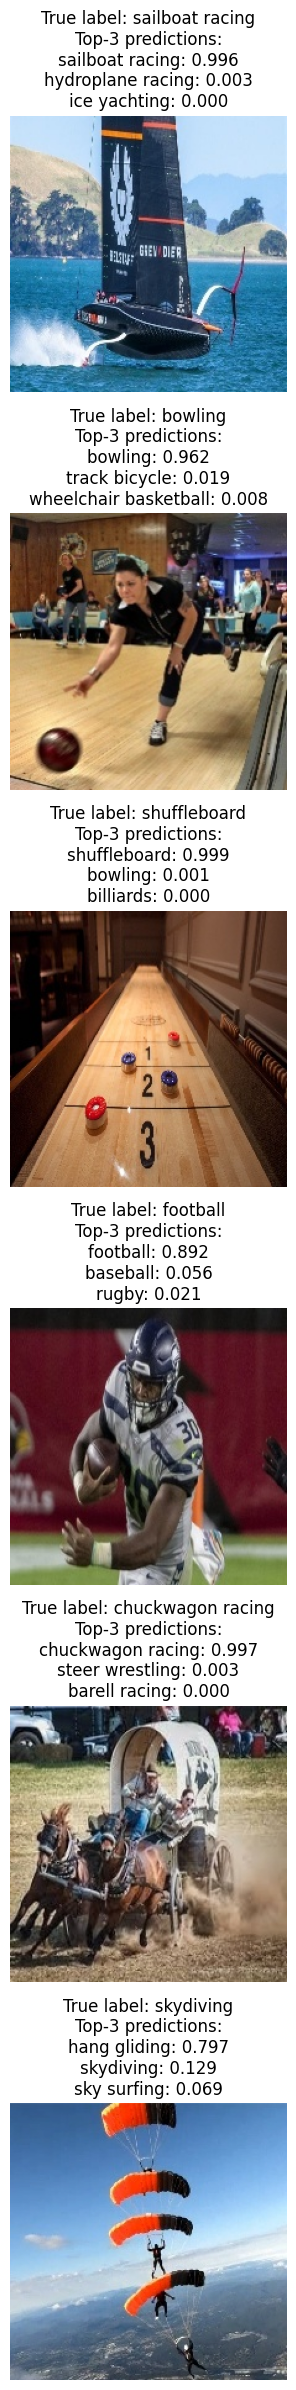

In [22]:
import torch

def load_trained_model_from_run(run_dir: Path):
    config_path = run_dir / "config_used.json"
    mapping_path = run_dir / "class_mapping.json"
    checkpoint_path = run_dir / "checkpoints" / "best_model.pt"

    if not (config_path.exists() and mapping_path.exists() and checkpoint_path.exists()):
        raise FileNotFoundError("Missing config, class mapping, or checkpoint for this run.")

    config = load_json(config_path)
    class_to_idx, idx_to_class = load_class_mapping(mapping_path)
    device = get_device()

    model = create_model(
        model_name=str(config["model_name"]),
        num_classes=len(class_to_idx),
        pretrained=False,
        freeze_backbone=False,
    ).to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    _, eval_transform = build_transforms(
        image_size=int(config["image_size"]),
        augmentation_mode="none",
    )

    return model, eval_transform, idx_to_class, device

def predict_one_image(model, transform, image_path: Path, idx_to_class, device, top_k=3):
    with Image.open(image_path) as img:
        tensor = transform(img.convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]
        top_probs, top_indices = torch.topk(probs, k=min(top_k, len(idx_to_class)))

    results = []
    for prob, idx in zip(top_probs.cpu().tolist(), top_indices.cpu().tolist()):
        results.append((idx_to_class[idx], float(prob)))
    return results

if best_row is None or not PROJECT_IMPORTS_OK:
    print("Prediction section is not available.")
else:
    best_run_dir = PROJECT_ROOT / best_row["run_dir"]
    test_csv = best_run_dir / "splits" / "test.csv"

    if not test_csv.exists():
        print("Saved test split CSV not found.")
    else:
        test_df = pd.read_csv(test_csv)
        if test_df.empty:
            print("Test split is empty.")
        else:
            model, eval_transform, idx_to_class, device = load_trained_model_from_run(best_run_dir)

            sample_df = test_df.sample(min(6, len(test_df)), random_state=42).reset_index(drop=True)

            fig, axes = plt.subplots(len(sample_df), 1, figsize=(10, 4 * len(sample_df)))
            if len(sample_df) == 1:
                axes = [axes]

            for ax, row in zip(axes, sample_df.to_dict(orient="records")):
                image_path = Path(row["path"])
                true_label = row["label"]
                preds = predict_one_image(model, eval_transform, image_path, idx_to_class, device, top_k=3)

                with Image.open(image_path) as img:
                    ax.imshow(img.convert("RGB"))
                pred_text = "\n".join([f"{name}: {prob:.3f}" for name, prob in preds])

                ax.set_title(f"True label: {true_label}\nTop-3 predictions:\n{pred_text}")
                ax.axis("off")

            plt.tight_layout()
            plt.show()


## 12. Conclusion

Three augmentation settings can be compared in a single place through saved training outputs.  
The notebook combines:
- numerical comparison of experiments,
- training curves,
- class distribution analysis,
- confusion matrix visualization,
- qualitative prediction examples.

Because it reads the saved outputs directly from the `outputs/` directory, it remains separate from the training code and does not affect the existing project implementation.
